In [12]:
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg') # Removed to allow inline display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import os

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# Adjust paths for Colab environment and ensure directories exist
CHARTS = '/content/charts'
DATA   = '/content/datasets'
os.makedirs(CHARTS, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

# ──────────────────────────────
# 1. GENERACIÓN DEL DATASET SIMULADO (RFM-like)
# ──────────────────────────────
N = 800

# Tres segmentos base con distribuciones distintas
seg_sizes = [300, 280, 220]   # Tamaños

def gen_segment(n, freq_mu, freq_sig, spend_mu, spend_sig,
                recency_mu, recency_sig, age_range, channel_probs):
    return {
        'frecuencia_compras': np.random.normal(freq_mu, freq_sig, n).clip(1, 60).astype(int),
        'gasto_medio_eur':    np.random.normal(spend_mu, spend_sig, n).clip(10, 2000).round(2),
        'dias_desde_ultima':  np.random.normal(recency_mu, recency_sig, n).clip(1, 365).astype(int),
        'edad':               np.random.randint(*age_range, n),
        'canal_preferido':    np.random.choice(['Online', 'Tienda física', 'App móvil'], n, p=channel_probs),
        'satisfaccion_nps':   np.random.normal(8.2 if spend_mu > 500 else 6.5, 1.5, n).clip(0, 10).round(1),
        'num_categorias':     np.random.randint(1, 8, n),
        'tiene_tarjeta_fid':  np.random.choice([0, 1], n, p=[0.3, 0.7] if spend_mu > 500 else [0.7, 0.3]),
    }

seg0 = gen_segment(seg_sizes[0], freq_mu=28, freq_sig=8,   spend_mu=720, spend_sig=200,
                   recency_mu=12, recency_sig=8,   age_range=(25, 50),
                   channel_probs=[0.55, 0.20, 0.25])
seg1 = gen_segment(seg_sizes[1], freq_mu=8,  freq_sig=4,   spend_mu=150, spend_sig=60,
                   recency_mu=90, recency_sig=45,  age_range=(35, 70),
                   channel_probs=[0.15, 0.70, 0.15])
seg2 = gen_segment(seg_sizes[2], freq_mu=4,  freq_sig=3,   spend_mu=45,  spend_sig=20,
                   recency_mu=200, recency_sig=60, age_range=(18, 35),
                   channel_probs=[0.40, 0.10, 0.50])

dfs = []
for seg, true_label in [(seg0, 0), (seg1, 1), (seg2, 2)]:
    df_tmp = pd.DataFrame(seg)
    df_tmp['true_segment'] = true_label
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df['cliente_id'] = [f'CLI_{i:04d}' for i in range(len(df))]

# Añadir ruido adicional para mayor realismo
df['gasto_total_anual'] = (df['frecuencia_compras'] * df['gasto_medio_eur']).round(2)
df['score_valor'] = (
    (df['frecuencia_compras'] / df['frecuencia_compras'].max()) * 40 +
    (df['gasto_medio_eur'] / df['gasto_medio_eur'].max()) * 40 +
    ((365 - df['dias_desde_ultima']) / 365) * 20
).round(1)

df.to_csv(f'{DATA}/clientes_dataset.csv', index=False)
print(f"✅ Dataset generado: {df.shape[0]} clientes × {df.shape[1]} variables")
print(df.describe().round(2))

# ──────────────────────────────
# 2. ANÁLISIS DESCRIPTIVO
# ──────────────────────────────
print("\n📊 Estadísticas descriptivas:")
print(df[['frecuencia_compras','gasto_medio_eur','dias_desde_ultima','satisfaccion_nps']].describe().round(2))

# ──────────────────────────────
# 3. CLUSTERING K-MEANS
# ──────────────────────────────
features = ['frecuencia_compras', 'gasto_medio_eur', 'dias_desde_ultima',
            'satisfaccion_nps', 'num_categorias', 'score_valor']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Método del codo
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Elegir K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
print(f"\n✅ K-Means convergido. Silhouette Score: {sil_final:.3f}")

# ──────────────────────────────
# 4. NOMBRAR PERFILES
# ──────────────────────────────
perfil_map = {}
centro_stats = df.groupby('cluster')[['gasto_medio_eur', 'frecuencia_compras', 'dias_desde_ultima']].mean()
for c in range(3):
    g = centro_stats.loc[c, 'gasto_medio_eur']
    f = centro_stats.loc[c, 'frecuencia_compras']
    r = centro_stats.loc[c, 'dias_desde_ultima']
    if g > 400 and f > 15:
        perfil_map[c] = 'Clientes Premium'
    elif r > 120:
        perfil_map[c] = 'Clientes Dormidos'
    else:
        perfil_map[c] = 'Clientes Ocasionales'

df['perfil'] = df['cluster'].map(perfil_map)
print("\nDistribución de perfiles:")
print(df['perfil'].value_counts())
df.to_csv(f'{DATA}/clientes_segmentados.csv', index=False)

# ──────────────────────────────
# 5. GRÁFICO 7: Método del Codo + Silhouette
# ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(K_range, inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
ax1.axvline(3, color='red', linestyle='--', alpha=0.7, label='K óptimo = 3')
ax1.set_title('Método del Codo (Inercia)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de clusters (K)'); ax1.set_ylabel('Inercia'); ax1.legend()

ax2.plot(K_range, sil_scores, 's-', color='#FF5722', linewidth=2.5, markersize=8)
ax2.axvline(3, color='red', linestyle='--', alpha=0.7, label='K óptimo = 3')
ax2.set_title('Silhouette Score por K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de clusters (K)'); ax2.set_ylabel('Silhouette Score'); ax2.legend()

fig.suptitle('Selección del Número Óptimo de Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS}/07_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 7 guardado: método del codo")

# ──────────────────────────────
# 6. GRÁFICO 8: PCA – Visualización 2D de clusters
# ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
palette = {'Clientes Premium': '#2196F3', 'Clientes Ocasionales': '#4CAF50', 'Clientes Dormidos': '#FF5722'}
for perfil, color in palette.items():
    mask = df['perfil'] == perfil
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=perfil, alpha=0.65, s=45, edgecolors='white', linewidths=0.3)

ax.set_title('Segmentación de Clientes – Visualización PCA', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza explicada)')
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{CHARTS}/08_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 8 guardado: PCA clusters")

# ──────────────────────────────
# 7. GRÁFICO 9: Radar / Perfil de cada segmento
# ──────────────────────────────
variables = ['Frecuencia\ncompras', 'Gasto\nmedio', 'Recencia\n(inv)', 'Satisfacción', 'Categorías', 'Score\nValor']
feat_cols  = ['frecuencia_compras', 'gasto_medio_eur', 'dias_desde_ultima', 'satisfaccion_nps', 'num_categorias', 'score_valor']

# Normalizar 0-1 para radar (invertir recencia)
norm_df = df.copy()
norm_df['dias_desde_ultima'] = 1 - (norm_df['dias_desde_ultima'] - norm_df['dias_desde_ultima'].min()) / \
    (norm_df['dias_desde_ultima'].max() - norm_df['dias_desde_ultima'].min())
for col in [c for c in feat_cols if c != 'dias_desde_ultima']:
    norm_df[col] = (norm_df[col] - norm_df[col].min()) / (norm_df[col].max() - norm_df[col].min())

means = norm_df.groupby('perfil')[feat_cols].mean()

N_var = len(variables)
angles = [n / float(N_var) * 2 * np.pi for n in range(N_var)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = list(palette.values())
for i, (perfil, row) in enumerate(means.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=colors_r[i], label=perfil)
    ax.fill(angles, vals, alpha=0.12, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(variables, size=11)
ax.set_title('Perfil Radar de Segmentos de Clientes', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{CHARTS}/09_radar_perfiles.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 9 guardado: radar de perfiles")

# ──────────────────────────────
# 8. GRÁFICO 10: Distribución de KPIs por perfil
# ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
kpis = [('gasto_medio_eur', 'Gasto Medio (€)'),
        ('frecuencia_compras', 'Frecuencia de Compras (anual)'),
        ('satisfaccion_nps', 'Satisfacción NPS'),
        ('dias_desde_ultima', 'Días desde óltima compra')]

for ax, (col, label) in zip(axes.flatten(), kpis):
    order = df.groupby('perfil')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='perfil', y=col, order=order,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Perfil de Cliente'); ax.set_ylabel(label)
    plt.setp(ax.get_xticklabels(), rotation=10)

fig.suptitle('Distribución de KPIs por Segmento de Cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS}/10_kpis_segmentos.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 10 guardado: KPIs por segmento")

# ──────────────────────────────
# 9. RESUMEN PARA INFORME
# ──────────────────────────────
resumen = df.groupby('perfil').agg(
    n_clientes=('cliente_id', 'count'),
    gasto_medio=('gasto_medio_eur', 'mean'),
    frecuencia_media=('frecuencia_compras', 'mean'),
    dias_media=('dias_desde_ultima', 'mean'),
    nps_medio=('satisfaccion_nps', 'mean'),
    gasto_anual_medio=('gasto_total_anual', 'mean'),
    pct_fidelizados=('tiene_tarjeta_fid', 'mean')
).round(2)
resumen['pct_clientes'] = (resumen['n_clientes'] / resumen['n_clientes'].sum() * 100).round(1)
resumen.to_csv(f'{DATA}/resumen_segmentos.csv')
print("\n📋 Resumen de segmentos:")
print(resumen.to_string())

print("\n✅ Segmentación completada.")

✅ Dataset generado: 800 clientes × 12 variables
       frecuencia_compras  gasto_medio_eur  dias_desde_ultima    edad  \
count              800.00           800.00             800.00  800.00   
mean                13.90           332.87              92.39   39.22   
std                 11.93           323.82              85.77   12.99   
min                  1.00            10.00               1.00   18.00   
25%                  4.00            62.16              15.00   29.00   
50%                  9.00           175.14              74.00   38.00   
75%                 24.00           622.50             150.00   47.00   
max                 58.00          1335.78             365.00   69.00   

       satisfaccion_nps  num_categorias  tiene_tarjeta_fid  true_segment  \
count            800.00          800.00             800.00         800.0   
mean               7.10            3.99               0.46           0.9   
std                1.64            2.01               0.50        

In [14]:
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg') # Removed to allow inline display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import os

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# Adjust paths for Colab environment and ensure directories exist
CHARTS = '/content/charts'
DATA   = '/content/datasets'
os.makedirs(CHARTS, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

# ──────────────────────────────
# 1. GENERACIÓN DEL DATASET SIMULADO (RFM-like)
# ──────────────────────────────
N = 800

# Tres segmentos base con distribuciones distintas
seg_sizes = [300, 280, 220]   # Tamaños

def gen_segment(n, freq_mu, freq_sig, spend_mu, spend_sig,
                recency_mu, recency_sig, age_range, channel_probs):
    return {
        'frecuencia_compras': np.random.normal(freq_mu, freq_sig, n).clip(1, 60).astype(int),
        'gasto_medio_eur':    np.random.normal(spend_mu, spend_sig, n).clip(10, 2000).round(2),
        'dias_desde_ultima':  np.random.normal(recency_mu, recency_sig, n).clip(1, 365).astype(int),
        'edad':               np.random.randint(*age_range, n),
        'canal_preferido':    np.random.choice(['Online', 'Tienda física', 'App móvil'], n, p=channel_probs),
        'satisfaccion_nps':   np.random.normal(8.2 if spend_mu > 500 else 6.5, 1.5, n).clip(0, 10).round(1),
        'num_categorias':     np.random.randint(1, 8, n),
        'tiene_tarjeta_fid':  np.random.choice([0, 1], n, p=[0.3, 0.7] if spend_mu > 500 else [0.7, 0.3]),
    }

seg0 = gen_segment(seg_sizes[0], freq_mu=28, freq_sig=8,   spend_mu=720, spend_sig=200,
                   recency_mu=12, recency_sig=8,   age_range=(25, 50),
                   channel_probs=[0.55, 0.20, 0.25])
seg1 = gen_segment(seg_sizes[1], freq_mu=8,  freq_sig=4,   spend_mu=150, spend_sig=60,
                   recency_mu=90, recency_sig=45,  age_range=(35, 70),
                   channel_probs=[0.15, 0.70, 0.15])
seg2 = gen_segment(seg_sizes[2], freq_mu=4,  freq_sig=3,   spend_mu=45,  spend_sig=20,
                   recency_mu=200, recency_sig=60, age_range=(18, 35),
                   channel_probs=[0.40, 0.10, 0.50])

dfs = []
for seg, true_label in [(seg0, 0), (seg1, 1), (seg2, 2)]:
    df_tmp = pd.DataFrame(seg)
    df_tmp['true_segment'] = true_label
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df['cliente_id'] = [f'CLI_{i:04d}' for i in range(len(df))]

# Añadir ruido adicional para mayor realismo
df['gasto_total_anual'] = (df['frecuencia_compras'] * df['gasto_medio_eur']).round(2)
df['score_valor'] = (
    (df['frecuencia_compras'] / df['frecuencia_compras'].max()) * 40 +
    (df['gasto_medio_eur'] / df['gasto_medio_eur'].max()) * 40 +
    ((365 - df['dias_desde_ultima']) / 365) * 20
).round(1)

df.to_csv(f'{DATA}/clientes_dataset.csv', index=False)
print(f"✅ Dataset generado: {df.shape[0]} clientes × {df.shape[1]} variables")
print(df.describe().round(2))

# ──────────────────────────────
# 2. ANÁLISIS DESCRIPTIVO
# ──────────────────────────────
print("\n📊 Estadísticas descriptivas:")
print(df[['frecuencia_compras','gasto_medio_eur','dias_desde_ultima','satisfaccion_nps']].describe().round(2))

# ──────────────────────────────
# 3. CLUSTERING K-MEANS
# ──────────────────────────────
features = ['frecuencia_compras', 'gasto_medio_eur', 'dias_desde_ultima',
            'satisfaccion_nps', 'num_categorias', 'score_valor']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Método del codo
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Elegir K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
print(f"\n✅ K-Means convergido. Silhouette Score: {sil_final:.3f}")

# ──────────────────────────────
# 4. NOMBRAR PERFILES
# ──────────────────────────────
perfil_map = {}
centro_stats = df.groupby('cluster')[['gasto_medio_eur', 'frecuencia_compras', 'dias_desde_ultima']].mean()
for c in range(3):
    g = centro_stats.loc[c, 'gasto_medio_eur']
    f = centro_stats.loc[c, 'frecuencia_compras']
    r = centro_stats.loc[c, 'dias_desde_ultima']
    if g > 400 and f > 15:
        perfil_map[c] = 'Clientes Premium'
    elif r > 120:
        perfil_map[c] = 'Clientes Dormidos'
    else:
        perfil_map[c] = 'Clientes Ocasionales'

df['perfil'] = df['cluster'].map(perfil_map)
print("\nDistribución de perfiles:")
print(df['perfil'].value_counts())
df.to_csv(f'{DATA}/clientes_segmentados.csv', index=False)

# ──────────────────────────────
# 5. GRÁFICO 7: Método del Codo + Silhouette
# ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(K_range, inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
ax1.axvline(3, color='red', linestyle='--', alpha=0.7, label='K óptimo = 3')
ax1.set_title('Método del Codo (Inercia)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de clusters (K)'); ax1.set_ylabel('Inercia'); ax1.legend()

ax2.plot(K_range, sil_scores, 's-', color='#FF5722', linewidth=2.5, markersize=8)
ax2.axvline(3, color='red', linestyle='--', alpha=0.7, label='K óptimo = 3')
ax2.set_title('Silhouette Score por K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de clusters (K)'); ax2.set_ylabel('Silhouette Score'); ax2.legend()

fig.suptitle('Selección del Número Óptimo de Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS}/07_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 7 guardado: método del codo")

# ──────────────────────────────
# 6. GRÁFICO 8: PCA – Visualización 2D de clusters
# ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
palette = {'Clientes Premium': '#2196F3', 'Clientes Ocasionales': '#4CAF50', 'Clientes Dormidos': '#FF5722'}
for perfil, color in palette.items():
    mask = df['perfil'] == perfil
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=perfil, alpha=0.65, s=45, edgecolors='white', linewidths=0.3)

ax.set_title('Segmentación de Clientes – Visualización PCA', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza explicada)')
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{CHARTS}/08_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 8 guardado: PCA clusters")

# ──────────────────────────────
# 7. GRÁFICO 9: Radar / Perfil de cada segmento
# ──────────────────────────────
variables = ['Frecuencia\ncompras', 'Gasto\nmedio', 'Recencia\n(inv)', 'Satisfacción', 'Categorías', 'Score\nValor']
feat_cols  = ['frecuencia_compras', 'gasto_medio_eur', 'dias_desde_ultima', 'satisfaccion_nps', 'num_categorias', 'score_valor']

# Normalizar 0-1 para radar (invertir recencia)
norm_df = df.copy()
norm_df['dias_desde_ultima'] = 1 - (norm_df['dias_desde_ultima'] - norm_df['dias_desde_ultima'].min()) / \
    (norm_df['dias_desde_ultima'].max() - norm_df['dias_desde_ultima'].min())
for col in [c for c in feat_cols if c != 'dias_desde_ultima']:
    norm_df[col] = (norm_df[col] - norm_df[col].min()) / (norm_df[col].max() - norm_df[col].min())

means = norm_df.groupby('perfil')[feat_cols].mean()

N_var = len(variables)
angles = [n / float(N_var) * 2 * np.pi for n in range(N_var)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = list(palette.values())
for i, (perfil, row) in enumerate(means.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=colors_r[i], label=perfil)
    ax.fill(angles, vals, alpha=0.12, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(variables, size=11)
ax.set_title('Perfil Radar de Segmentos de Clientes', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{CHARTS}/09_radar_perfiles.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 9 guardado: radar de perfiles")

# ──────────────────────────────
# 8. GRÁFICO 10: Distribución de KPIs por perfil
# ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
kpis = [('gasto_medio_eur', 'Gasto Medio (€)'),
        ('frecuencia_compras', 'Frecuencia de Compras (anual)'),
        ('satisfaccion_nps', 'Satisfacción NPS'),
        ('dias_desde_ultima', 'Días desde óltima compra')]

for ax, (col, label) in zip(axes.flatten(), kpis):
    order = df.groupby('perfil')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='perfil', y=col, order=order,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Perfil de Cliente'); ax.set_ylabel(label)
    plt.setp(ax.get_xticklabels(), rotation=10)

fig.suptitle('Distribución de KPIs por Segmento de Cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS}/10_kpis_segmentos.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 10 guardado: KPIs por segmento")

# ──────────────────────────────
# 9. RESUMEN PARA INFORME
# ──────────────────────────────
resumen = df.groupby('perfil').agg(
    n_clientes=('cliente_id', 'count'),
    gasto_medio=('gasto_medio_eur', 'mean'),
    frecuencia_media=('frecuencia_compras', 'mean'),
    dias_media=('dias_desde_ultima', 'mean'),
    nps_medio=('satisfaccion_nps', 'mean'),
    gasto_anual_medio=('gasto_total_anual', 'mean'),
    pct_fidelizados=('tiene_tarjeta_fid', 'mean')
).round(2)
resumen['pct_clientes'] = (resumen['n_clientes'] / resumen['n_clientes'].sum() * 100).round(1)
resumen.to_csv(f'{DATA}/resumen_segmentos.csv')
print("\n📋 Resumen de segmentos:")
print(resumen.to_string())

print("\n✅ Segmentación completada.")

✅ Dataset generado: 800 clientes × 12 variables
       frecuencia_compras  gasto_medio_eur  dias_desde_ultima    edad  \
count              800.00           800.00             800.00  800.00   
mean                13.90           332.87              92.39   39.22   
std                 11.93           323.82              85.77   12.99   
min                  1.00            10.00               1.00   18.00   
25%                  4.00            62.16              15.00   29.00   
50%                  9.00           175.14              74.00   38.00   
75%                 24.00           622.50             150.00   47.00   
max                 58.00          1335.78             365.00   69.00   

       satisfaccion_nps  num_categorias  tiene_tarjeta_fid  true_segment  \
count            800.00          800.00             800.00         800.0   
mean               7.10            3.99               0.46           0.9   
std                1.64            2.01               0.50        

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure that the palette only contains colors for existing profiles
existing_profiles = df['perfil'].unique()
active_palette = {k: v for k, v in palette.items() if k in existing_profiles}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Adicional de Perfiles de Clientes', fontsize=16, fontweight='bold')

# Plot 1: Histograma de edades (arriba a la izquierda)
sns.histplot(df['edad'], bins=20, kde=True, ax=axes[0, 0], color=active_palette.get('Clientes Premium', '#2196F3')) # Use a generic color if no premium
axes[0, 0].set_title('Distribución de Edades', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')

# Plot 2: Boxplot de gasto medio por perfil (arriba a la derecha)
sns.boxplot(data=df, x='perfil', y='gasto_medio_eur', ax=axes[0, 1], palette=active_palette, order=existing_profiles)
axes[0, 1].set_title('Gasto Medio por Perfil de Cliente', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Perfil de Cliente')
axes[0, 1].set_ylabel('Gasto Medio (€)')
plt.setp(axes[0, 1].get_xticklabels(), rotation=10)

# Generate synthetic 'riesgo' and 'uso_digital' for the scatter plot
df['uso_digital'] = df['canal_preferido'].map({'Online': 2, 'App móvil': 3, 'Tienda física': 1})
# Simple synthetic risk score: higher recency, lower score_valor, no fidelity card -> higher risk
df['riesgo'] = (df['dias_desde_ultima'] / df['dias_desde_ultima'].max()) * 50 + \
               (1 - (df['score_valor'] / df['score_valor'].max())) * 30 + \
               (1 - df['tiene_tarjeta_fid']) * 20
df['riesgo'] = df['riesgo'].round(1) # Round for cleaner values

# Plot 3: Scatter de riesgo vs. uso digital (abajo a la izquierda)
# Using `hue` to differentiate by 'perfil'
sns.scatterplot(data=df, x='uso_digital', y='riesgo', hue='perfil',
                palette=active_palette, ax=axes[1, 0], s=80, alpha=0.7, edgecolor='w')
axes[1, 0].set_title('Riesgo vs. Uso Digital por Perfil', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Uso Digital (1:Tienda Física, 2:Online, 3:App Móvil)')
axes[1, 0].set_ylabel('Nivel de Riesgo (Sintético)')
# Adjust x-ticks to show labels for better understanding
axes[1, 0].set_xticks([1, 2, 3])
axes[1, 0].set_xticklabels(['Tienda Física', 'Online', 'App Móvil'])
axes[1, 0].legend(title='Perfil')

# Plot 4: Barras de perfil comparativo (abajo a la derecha - Gasto Total Anual)
avg_gasto_anual_perfil = df.groupby('perfil')['gasto_total_anual'].mean().reindex(existing_profiles).sort_values(ascending=False)
sns.barplot(x=avg_gasto_anual_perfil.index, y=avg_gasto_anual_perfil.values, ax=axes[1, 1], palette=active_palette)
axes[1, 1].set_title('Gasto Total Anual Medio por Perfil', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Perfil de Cliente')
axes[1, 1].set_ylabel('Gasto Total Anual Medio (€)')
plt.setp(axes[1, 1].get_xticklabels(), rotation=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.savefig(f'{CHARTS}/11_additional_profile_analysis.png', dpi=150, bbox_inches='tight')
plt.show() # Added plt.show()
# plt.close() # Removed plt.close()
print("📊 Gráfico 11 guardado: Análisis adicional de perfiles")

📊 Gráfico 11 guardado: Análisis adicional de perfiles


Found 5 image files in /content/charts:

--- Displaying: 07_elbow_silhouette.png ---


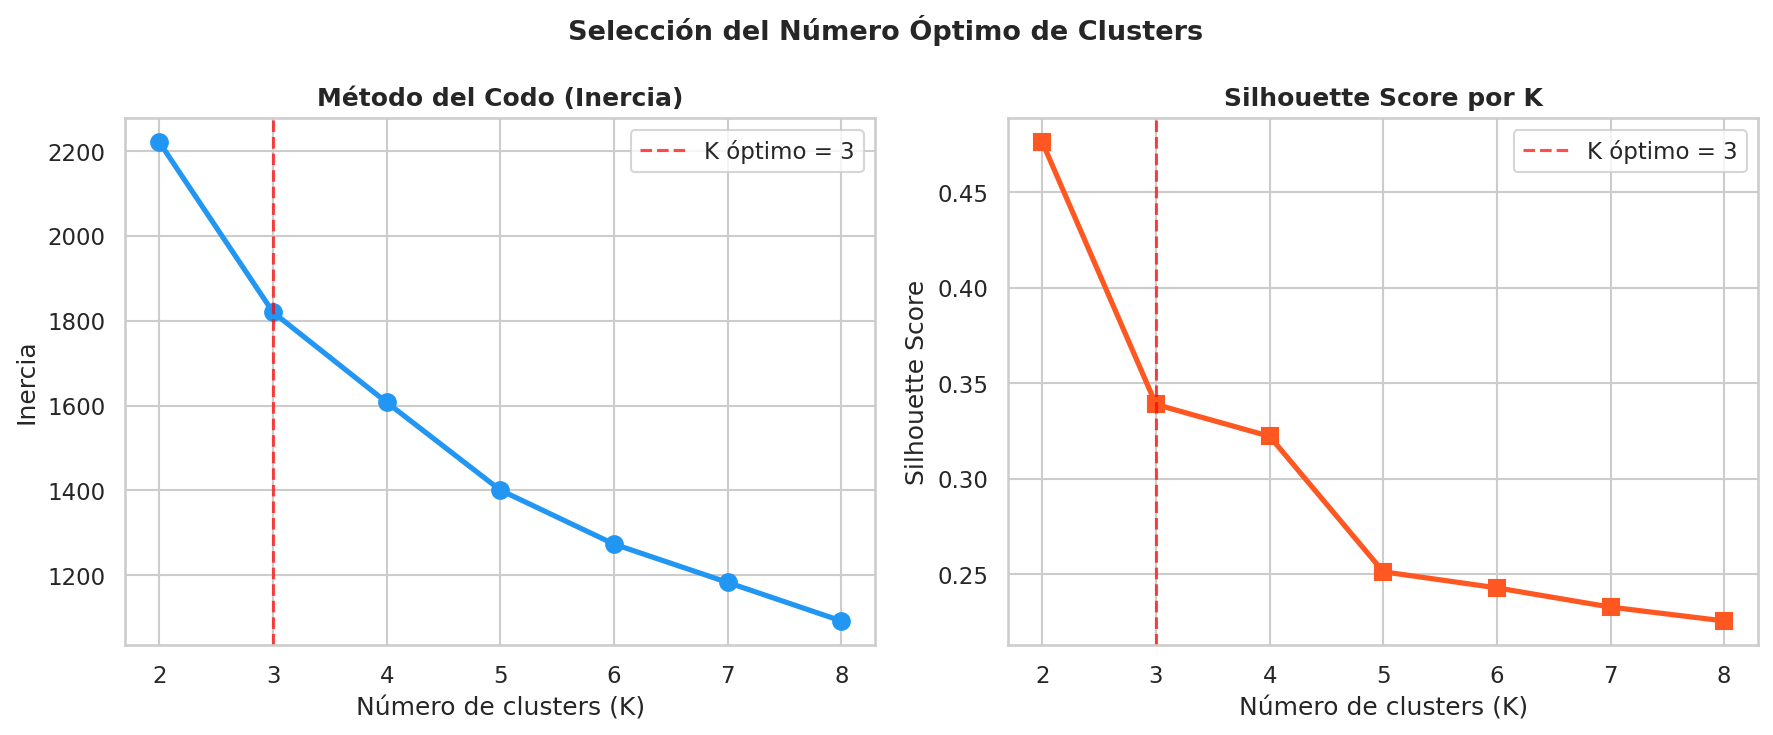


--- Displaying: 08_pca_clusters.png ---


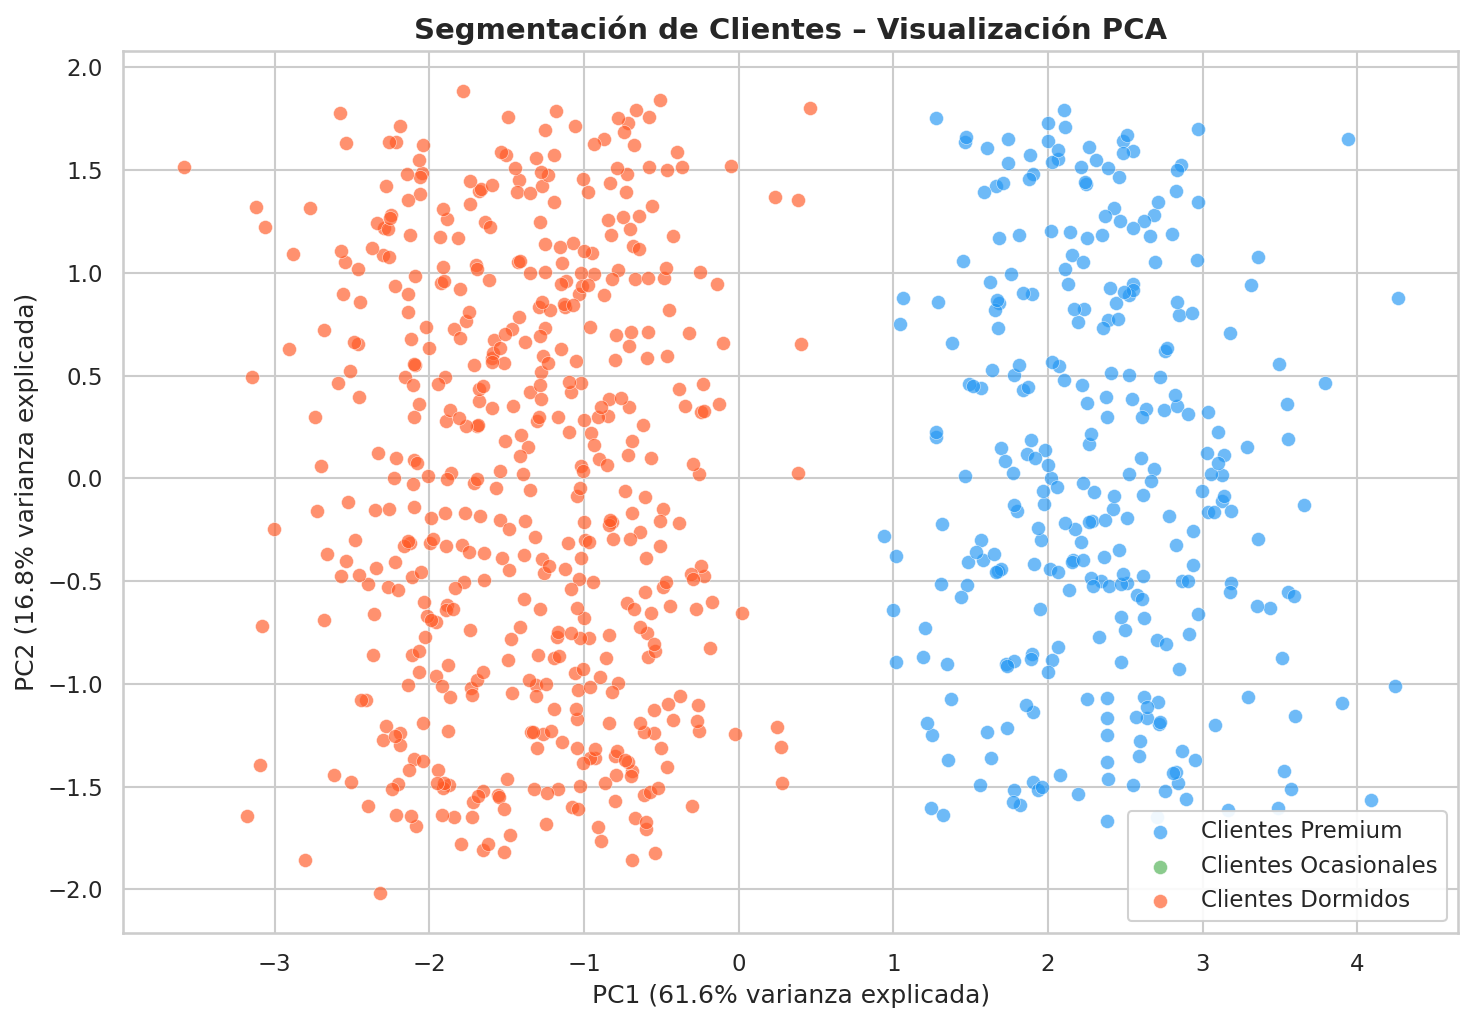


--- Displaying: 09_radar_perfiles.png ---


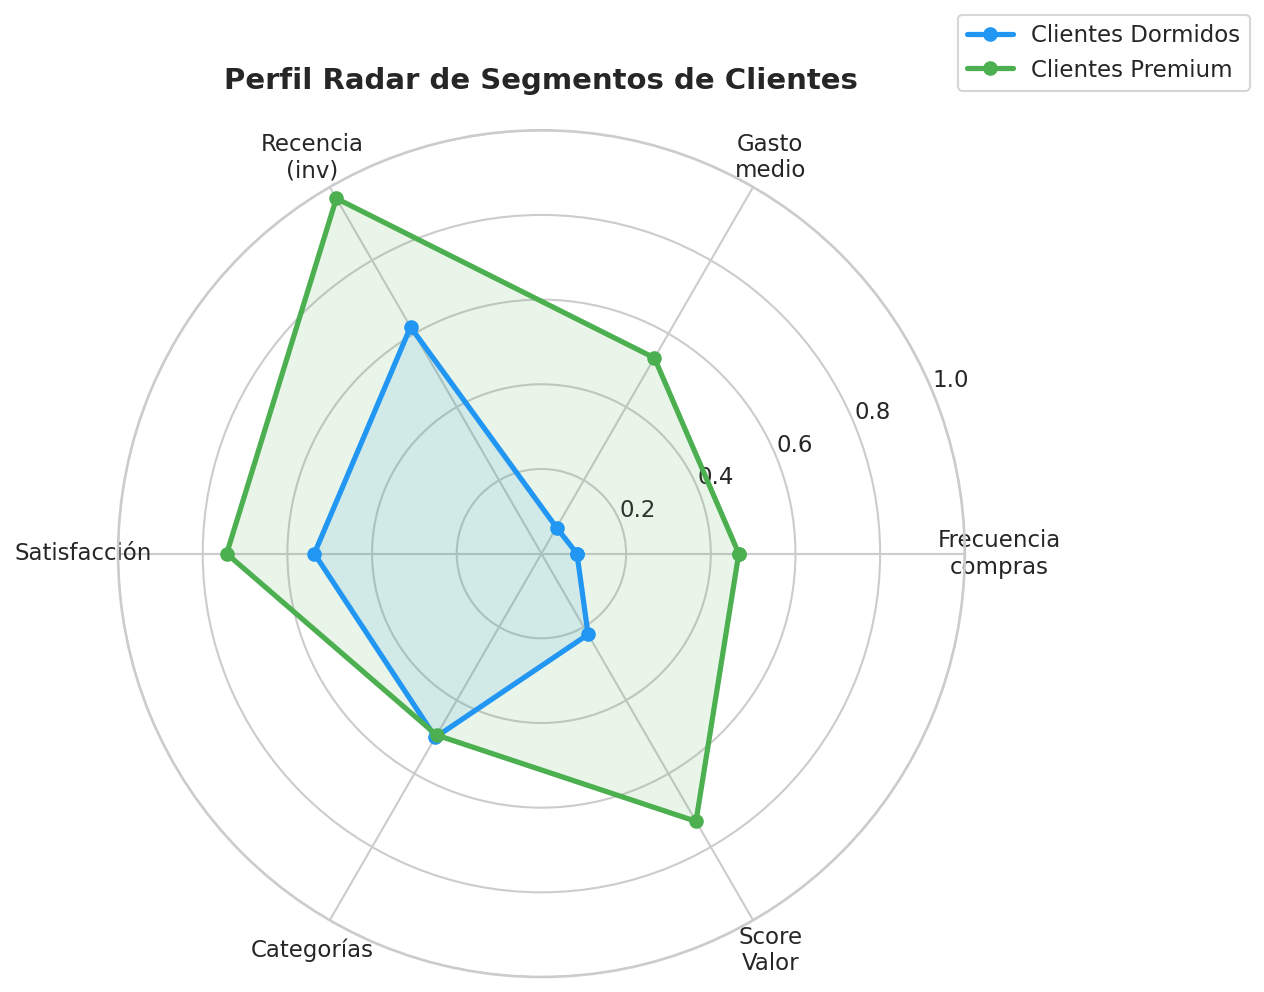


--- Displaying: 10_kpis_segmentos.png ---


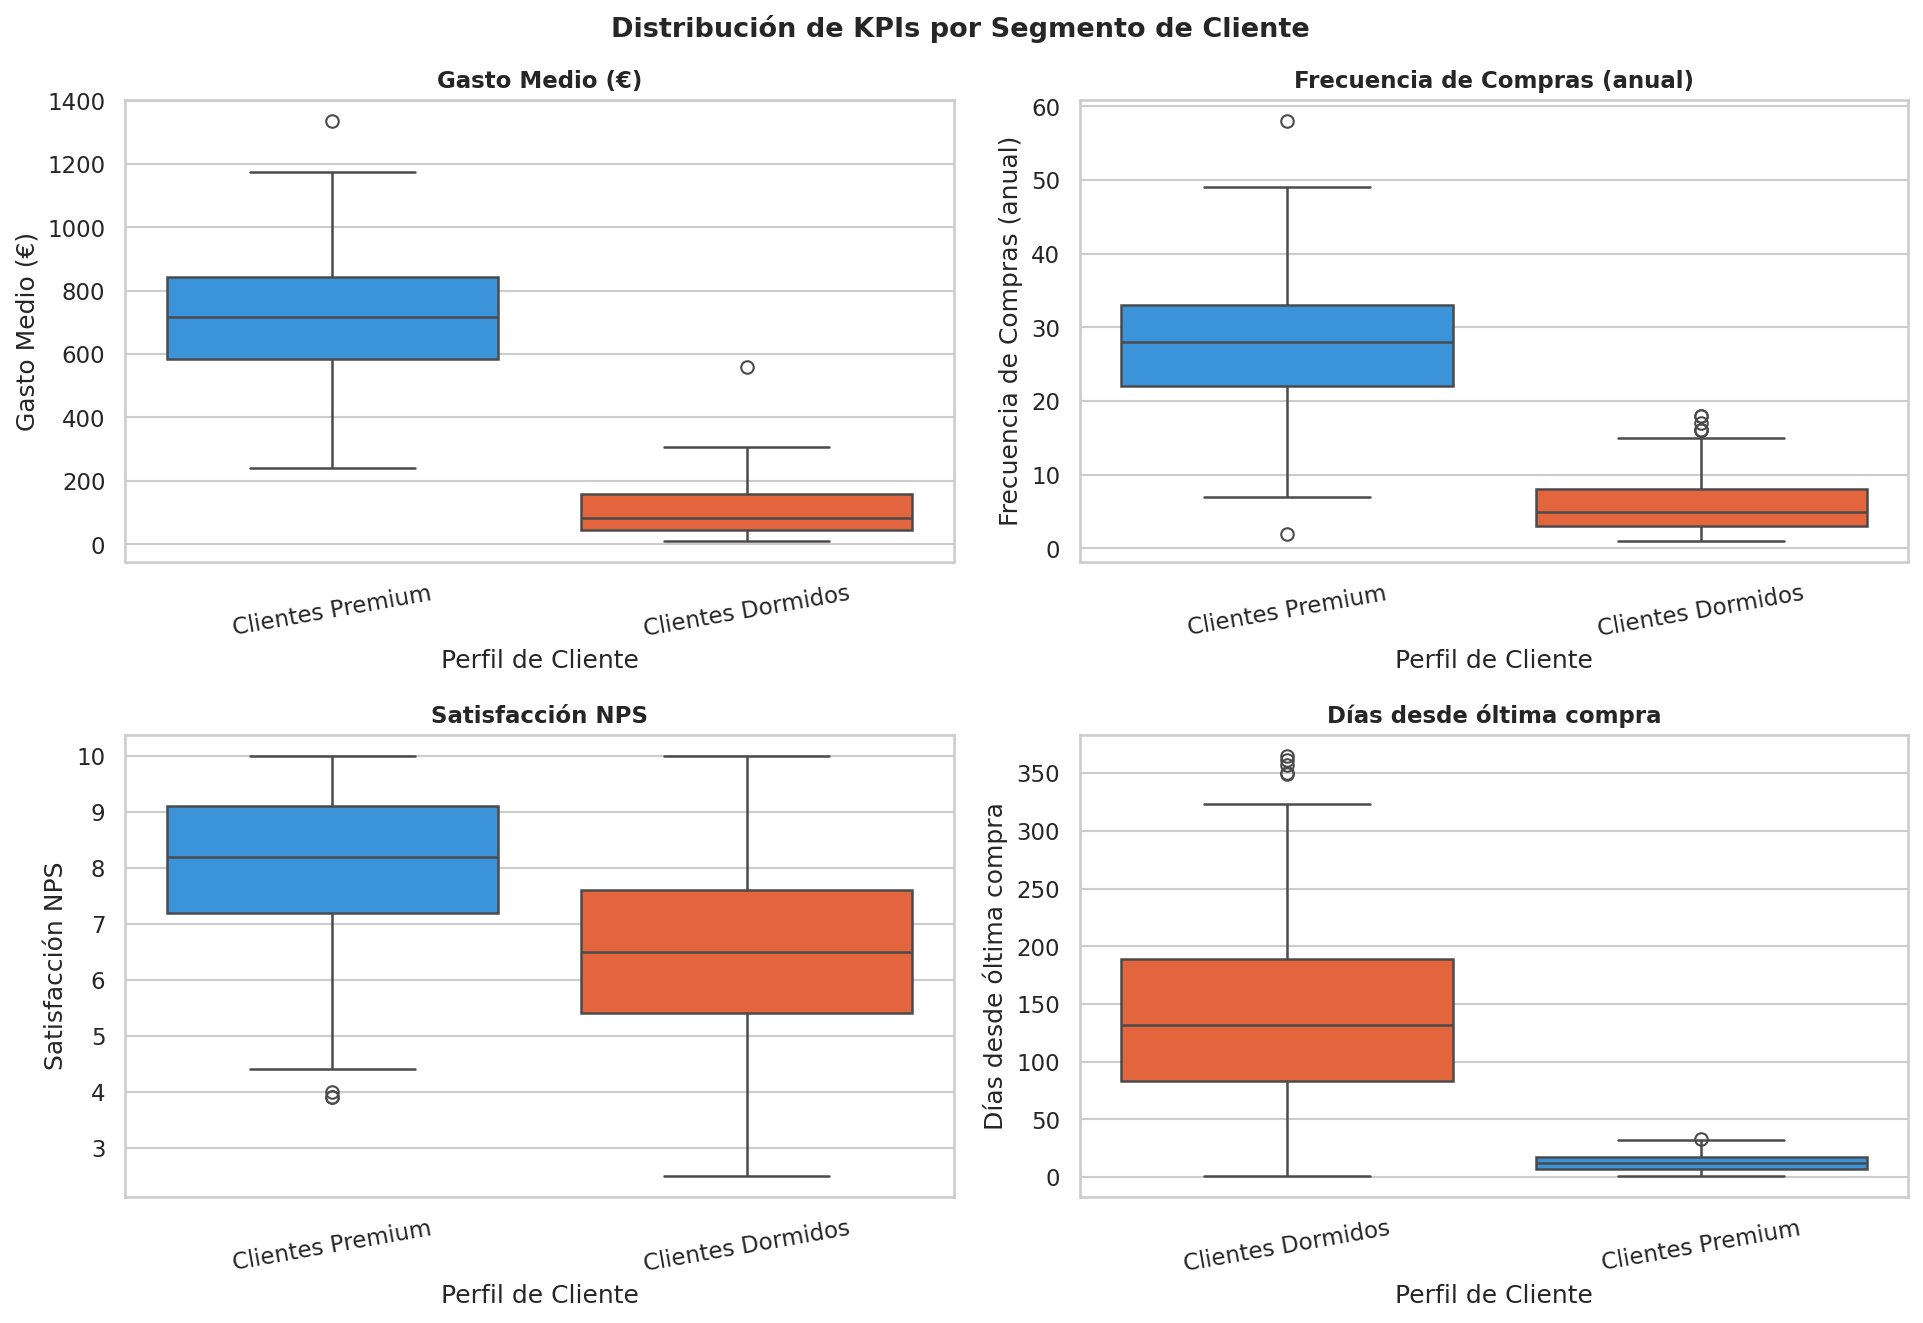


--- Displaying: 11_additional_profile_analysis.png ---


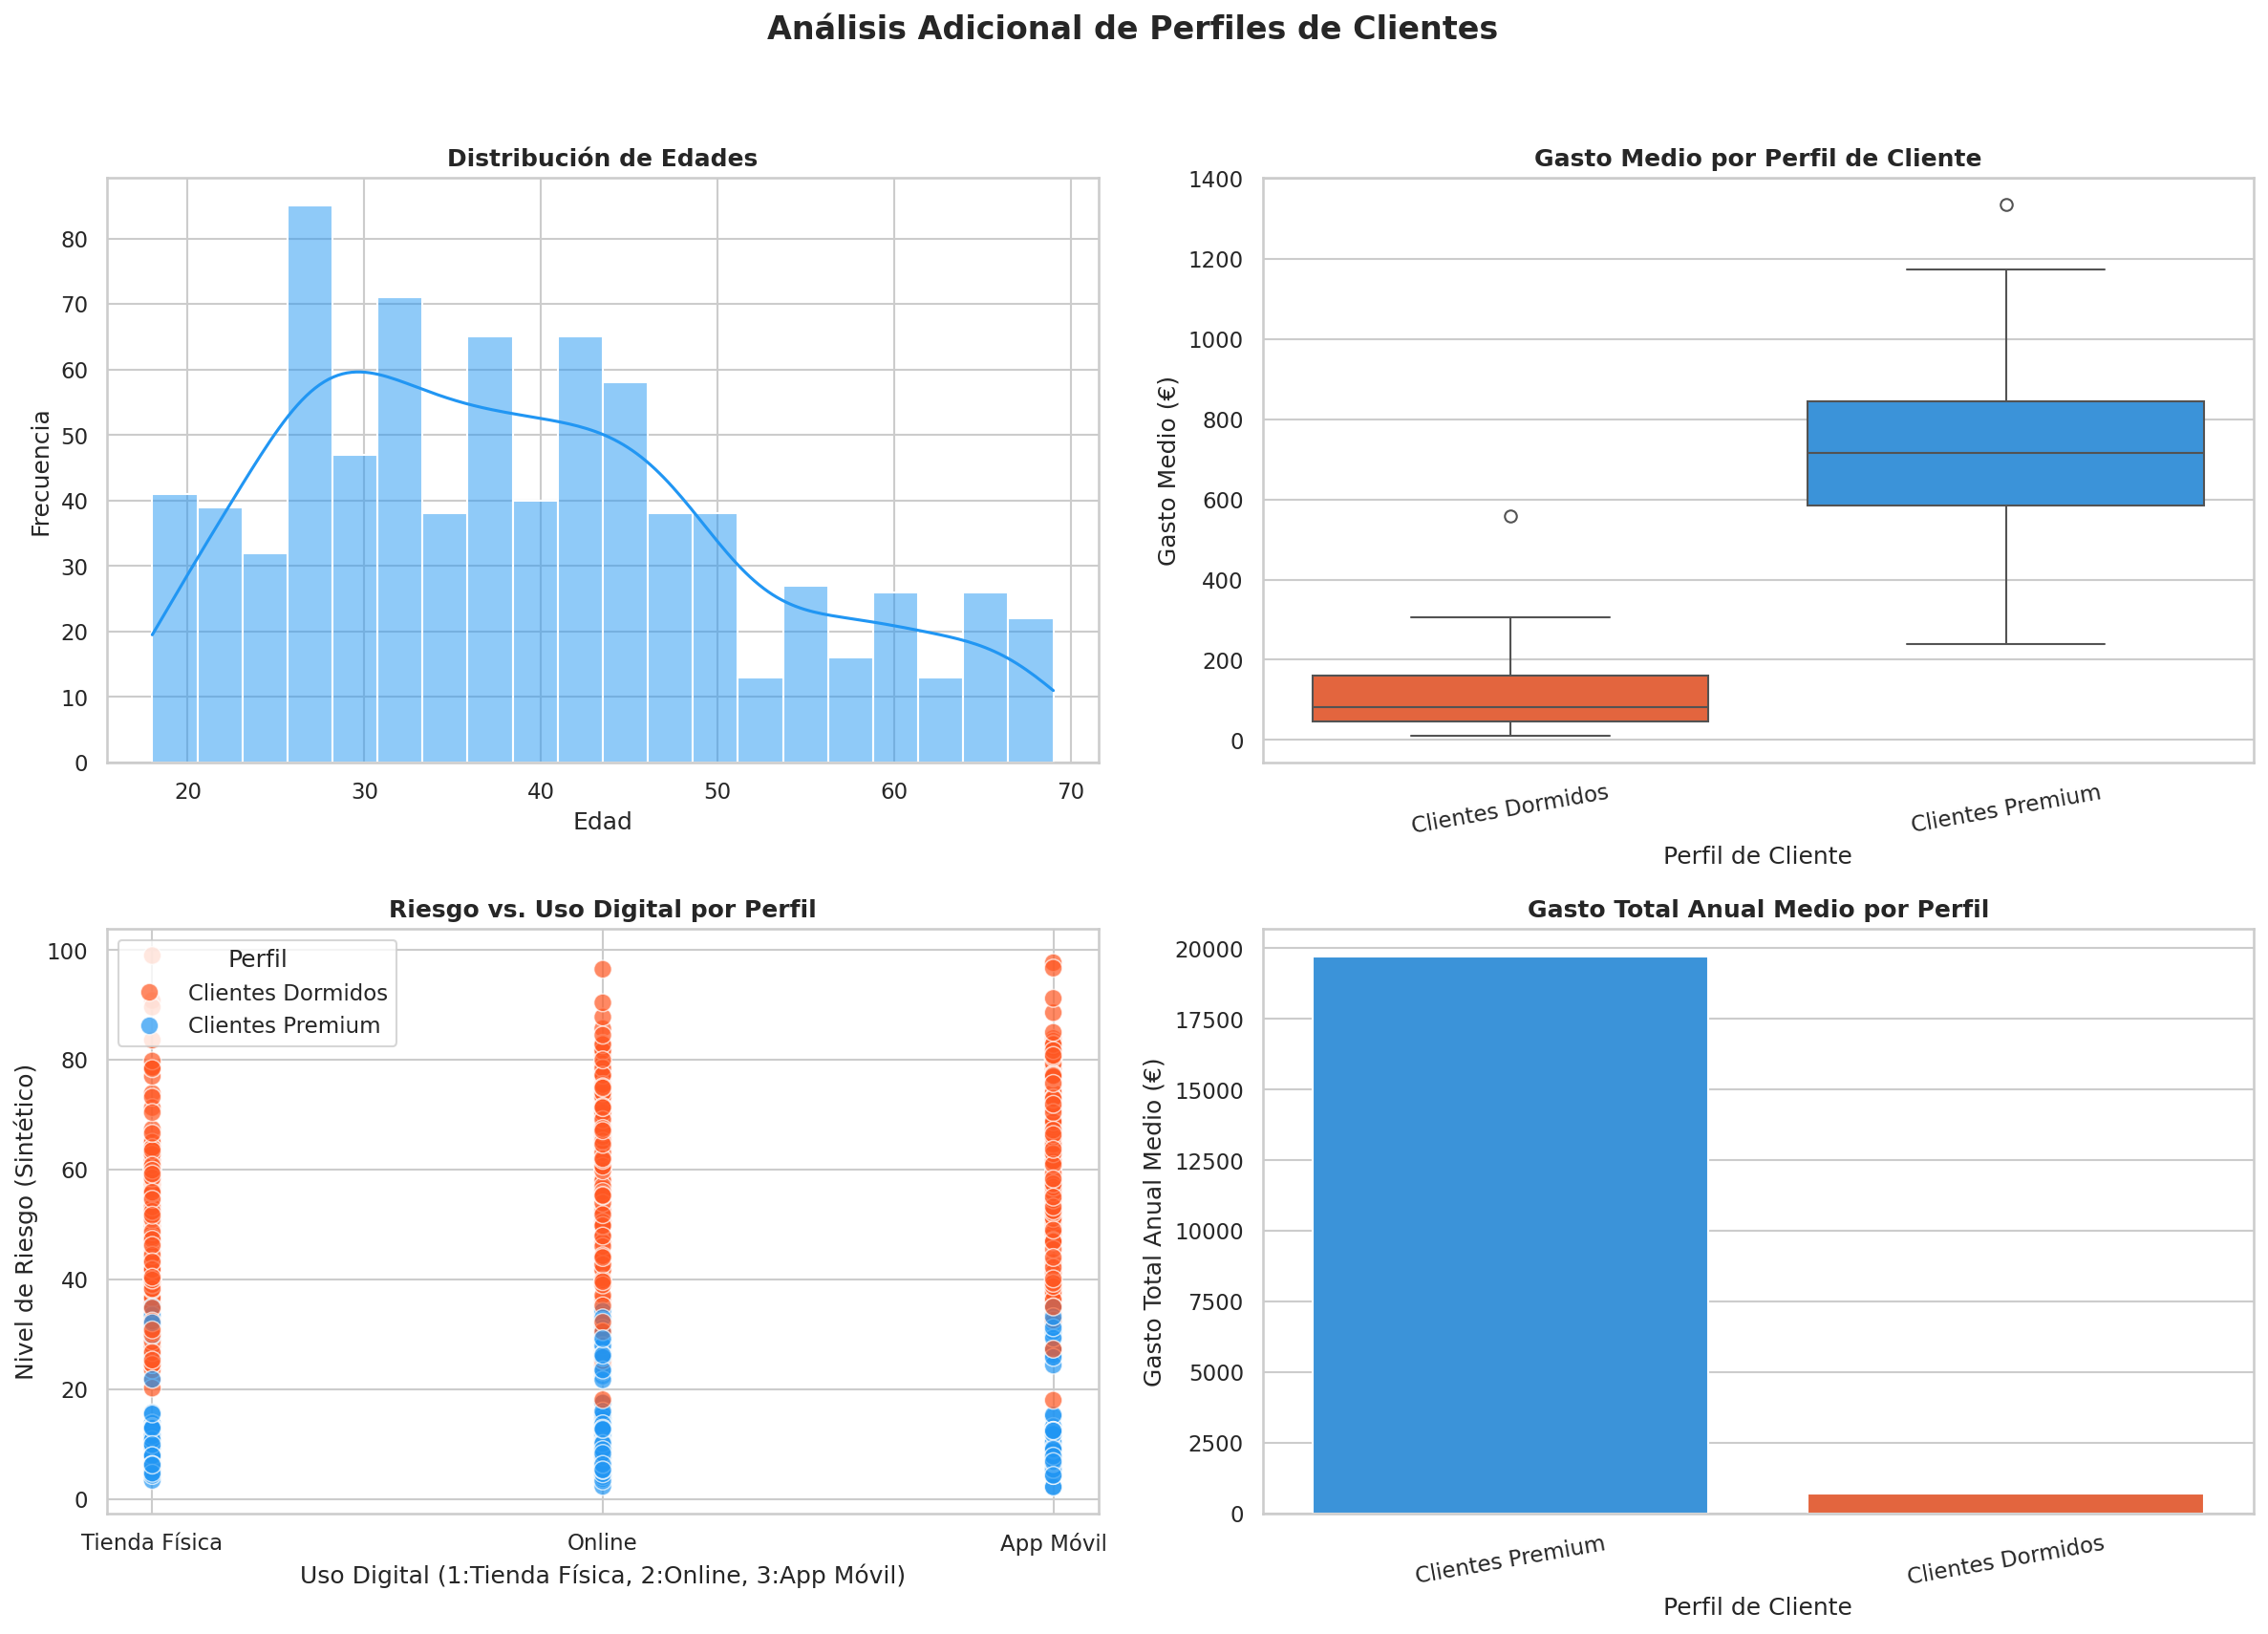

In [16]:
from IPython.display import Image, display
import os

# Define the directory where charts are saved
charts_dir = '/content/charts'

# Get a list of all PNG files in the charts directory, sorted by name
image_files = sorted([f for f in os.listdir(charts_dir) if f.endswith('.png')])

print(f"Found {len(image_files)} image files in {charts_dir}:")

for img_file in image_files:
    img_path = os.path.join(charts_dir, img_file)
    print(f"\n--- Displaying: {img_file} ---")
    try:
        display(Image(filename=img_path))
    except Exception as e:
        print(f"Error displaying {img_file}: {e}")